**Задача**

Используется набор данных Ames Housing.
Необходимо сравнить цены домов (SalePrice) в двух группах.

Группы формируются по значению количественной переменной относительно её медианы. Впоследствии мы обоснуем выбор именно медианы в качестве центра распределения.

Общее число наблюдений: 2930

Анализ проводится дважды для двух различных переменных:

1. Overall Qual
2. Total Bsmt SF

Уровень значимости α = 0,05

**Описание переменных:**

1. Overall Qual — общая оценка качества дома (шкала 1–10).
2. Total Bsmt SF — общая площадь подвала.

Формируем по ним новые групповые переменные:

qual_group = 1, если Overall Qual > median
qual_group = 0, если Overall Qual ≤ median

bsmt_group = 1, если Total Bsmt SF > median
bsmt_group = 0, если Total Bsmt SF ≤ median



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Загрузка данных
data = pd.read_csv("AmesHousing.txt", delimiter = "\t")
print(data.describe())
# Удаляем пропуски
df = data[["Total Bsmt SF", "Overall Qual", "SalePrice"]].dropna()
# Первая переменная
# Медиана группирующей переменной
qual_median = df["Overall Qual"].median()
print(f"Медиана Overall Qual: {qual_median}")

# Формирование групп
df["qual_group"] = np.where(df['Overall Qual'] > qual_median, 1, 0)

group0 = df[df["qual_group"] == 0]["SalePrice"]
group1 = df[df["qual_group"] == 1]["SalePrice"]

# Вторая переменная
# Медиана группирующей переменной
bsmt_median = df["Total Bsmt SF"].median()
print(f"Медиана Total Bsmt SF: {bsmt_median}")

# Формирование групп
df["bsmt_group"] = np.where(df['Total Bsmt SF'] > bsmt_median, 1, 0)

group2 = df[df["bsmt_group"] == 0]["SalePrice"]
group3 = df[df["bsmt_group"] == 1]["SalePrice"]

            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026      1.111537    30.245361       20.860286    

**Проверка нормальности распределения SalePrice**

Проверяем гипотезу отдельно для каждой группы:

<p>H₀: распределение SalePrice нормальное</p>
<p>H₁: распределение не является нормальным</p>

Посмотрим, что покажут критерии Колмогорова-Смирнова или Шапиро-Уилка. Рассчитаем соответствующие статистики и p-value.


In [ ]:
# Проверка нормальности Шапиро–Уилка в четырех группах

shapiro0 = stats.shapiro(group0)
shapiro1 = stats.shapiro(group1)
shapiro2 = stats.shapiro(group2)
shapiro3 = stats.shapiro(group3)

# Первая переменная - Overall Qual
print(f"Group 0: shapiro p-value = {shapiro0.pvalue}")
print(f"Group 1: shapiro p-value = {shapiro1.pvalue}")

# Вторая перменная - Total Bsmt SF
print(f"Group 2: shapiro p-value = {shapiro2.pvalue}")
print(f"Group 3: shapiro p-value = {shapiro3.pvalue}")

Group 0: shapiro p-value = 1.0070792178152568e-16
Group 1: shapiro p-value = 5.596187293192608e-27
Group 2: shapiro p-value = 4.0576078610703475e-16
Group 3: shapiro p-value = 4.462396448079055e-31


In [ ]:
# Проверка нормальности Колмогорова-Смирнова в четырех группах

groups = [group0,group1,group2,group3]
for i in range(4):
    # Оценка параметров
    mu = groups[i].mean()
    sigma = groups[i].std(ddof=1)
    # Стандартизация
    z = (groups[i] - mu) / sigma

    # KS test
    kolmogorov = stats.kstest(z, 'norm')
    print(f"Group {i}: kstest p-value = {kolmogorov.pvalue}")


Group 0: kstest p-value = 1.4029327933794672e-06
Group 1: kstest p-value = 1.5129148789960612e-11
Group 2: kstest p-value = 5.168689414893737e-08
Group 3: kstest p-value = 8.64211337943999e-15


В обоих случаях Sig. = .00 < α = 0,05 <=> гипотеза нормальности отвергается.

Посмотрим гистограммы по группам и сравним с нормальным распределением:



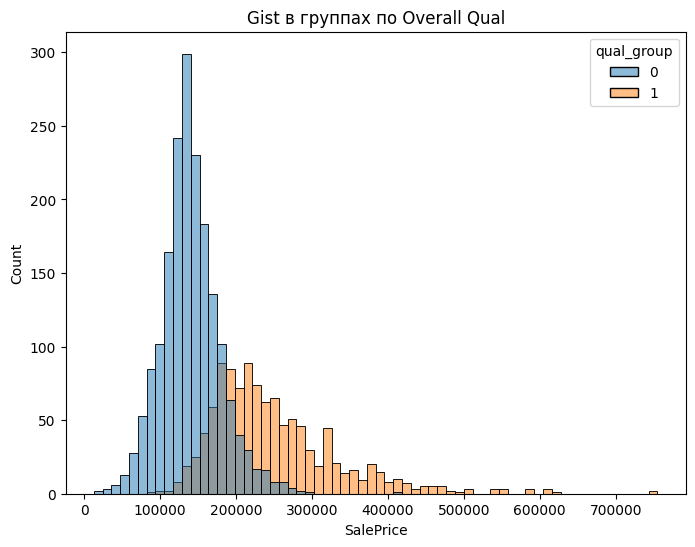

In [ ]:
# Гистограммы для групп по переменной Overall Qual
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='SalePrice', hue='qual_group')

plt.title("Gist в группах по Overall Qual")
plt.xlabel("SalePrice")
plt.show()

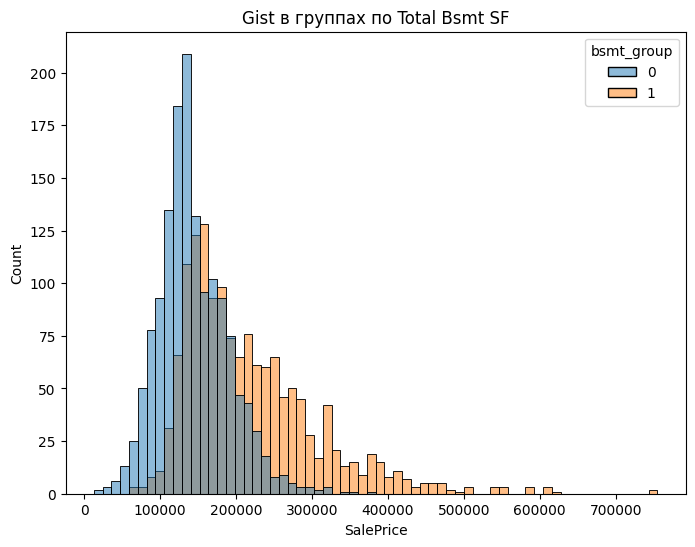

In [ ]:
# Гистограммы для групп по переменной Total Bsmt SF
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='SalePrice', hue='bsmt_group')

plt.title("Gist в группах по Total Bsmt SF")
plt.xlabel("SalePrice")
plt.show()

**Выбор критерия**

Гистограмма первой группы визуально напоминает нормальное распределение. Однако визуальная оценка не является достаточной. Формальные критерии нормальности и анализ выбросов показывают отклонение от нормального распределения. Кроме того, распределение цен характеризуется тяжёлыми хвостами, что делает среднее нестабильной характеристикой. Приходим к выводу, что все группы так или иначе существенно отличаются от нормального распределения. В связи с этим для сравнения групп используется непараметрический критерий Манна–Уитни для гипотезе о равенстве медиан.


**Проверяемая гипотеза для переменной Overall Qual**

H₀: медианы SalePrice в двух группах равны

H₁: медианы различаются

**Результат проверки**

In [ ]:
#Критерий Манна–Уитни для первой переменной

mw = stats.mannwhitneyu(group0, group1, alternative='two-sided')
print(f"U-статистика = {mw.statistic}")
print(f"p-value = {mw.pvalue}")

if mw.pvalue < 0.05:
    print("Гипотеза о равенстве медиан отвергается.")
else:
    print("Нет оснований отвергнуть гипотезу о равенстве медиан.")

U-статистика = 152187.0
p-value = 0.0
Гипотеза о равенстве медиан отвергается.


**Интерпретация**

Медианная цена домов с качеством выше медианы статистически значимо больше, чем у домов с качеством ниже медианы.

Ящиковая диаграмма демонстрирует:

1. отчётливый сдвиг медианы вверх
2. меньшее перекрытие межквартильных интервалов
3. наличие выбросов

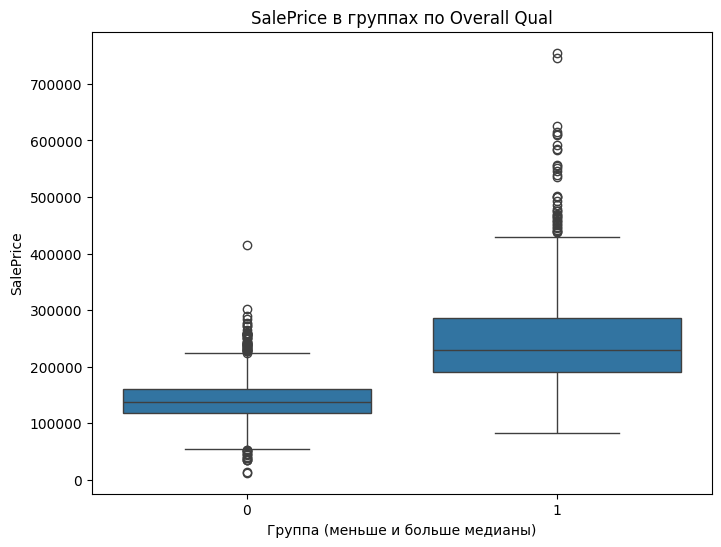

In [ ]:
# Строим boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x="qual_group", y="SalePrice", data=df)

plt.title("SalePrice в группах по Overall Qual")
plt.xlabel("Группа (меньше и больше медианы)")
plt.ylabel("SalePrice")
plt.show()

**Проверяемая гипотеза для переменной Total Bsmt SF**

H₀: медианы равны

H₁: медианы различаются

**Результат проверки**

In [ ]:
#Критерий Манна–Уитни для второй переменной

mw = stats.mannwhitneyu(group2, group3, alternative='two-sided')
print(f"U-статистика = {mw.statistic}")
print(f"p-value = {mw.pvalue}")

if mw.pvalue < 0.05:
    print("Гипотеза о равенстве медиан отвергается.")
else:
    print("Нет оснований отвергнуть гипотезу о равенстве медиан.")

U-статистика = 464073.0
p-value = 1.100066991628179e-155
Гипотеза о равенстве медиан отвергается.


**Интерпретация**

Дома с площадью подвала выше медианы имеют статистически значимо более высокую цену.

Ящиковая диаграмма показывает заметный сдвиг распределения вверх во второй группе.

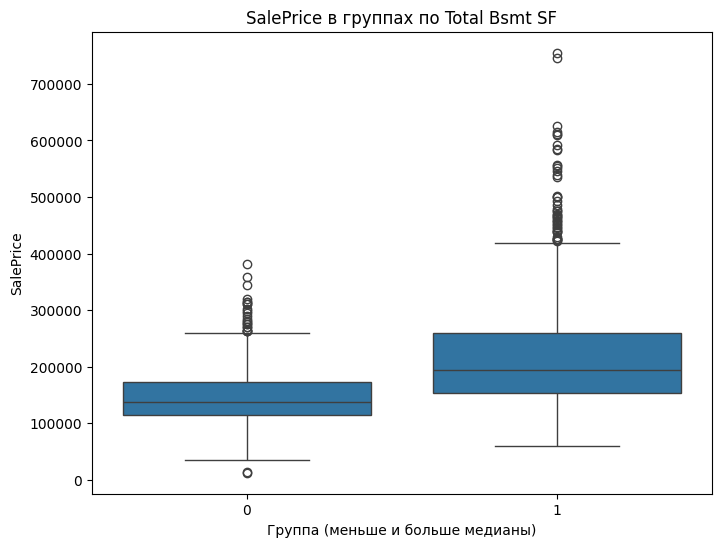

In [ ]:
# Строим boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x="bsmt_group", y="SalePrice", data=df)

plt.title("SalePrice в группах по Total Bsmt SF")
plt.xlabel("Группа (меньше и больше медианы)")
plt.ylabel("SalePrice")
plt.show()

**Общий вывод**

В наборе Ames Housing качество дома и площадь подвала статистически значимо связаны с ценой продажи.